In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/raw_superstore.csv')
df['sales'] = df['sales'].str.replace(',', '').astype(float)
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


In [2]:
features = ['sales', 'discount', 'quantity', 'category', 'region']
target = 'profit'

df_model = df[features + [target]].dropna()

df_model = pd.get_dummies(df_model, columns=['category', 'region'], drop_first=True)

df_model.head()

,sales,discount,quantity,profit,category_Office Supplies,category_Technology,region_Canada,region_Caribbean,region_Central,region_Central Asia,region_EMEA,region_East,region_North,region_North Asia,region_Oceania,region_South,region_Southeast Asia,region_West
0,408.0,0.0,2,106.140,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,120.0,0.1,3,36.036,True,False,False,False,False,False,False,False,False,False,True,False,False,False
2,66.0,0.0,4,29.640,True,False,False,False,False,False,True,False,False,False,False,False,False,False
3,45.0,0.5,3,-26.055,True,False,False,False,False,False,False,False,True,False,False,False,False,False
4,114.0,0.1,5,37.770,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [3]:
X = df_model.drop(columns=['profit'])
y = df_model['profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 41032
Testing rows: 10258


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [5]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 60.36
RMSE: 141.62
R²: 0.39


In [ ]:
#An R² of 0.39 with just 5 straightforward features on noisy, real-world transaction data is a reasonable baseline, not a failure. It confirms discount and category meaningfully drive profit — which matches what I found in my SQL/EDA work — but there's clearly more complexity in individual order profitability than these features alone capture. A next step would be adding more features (like shipping cost, sub-category, or order priority) or trying a non-linear model like Random Forest to see if it captures more of that complexity.

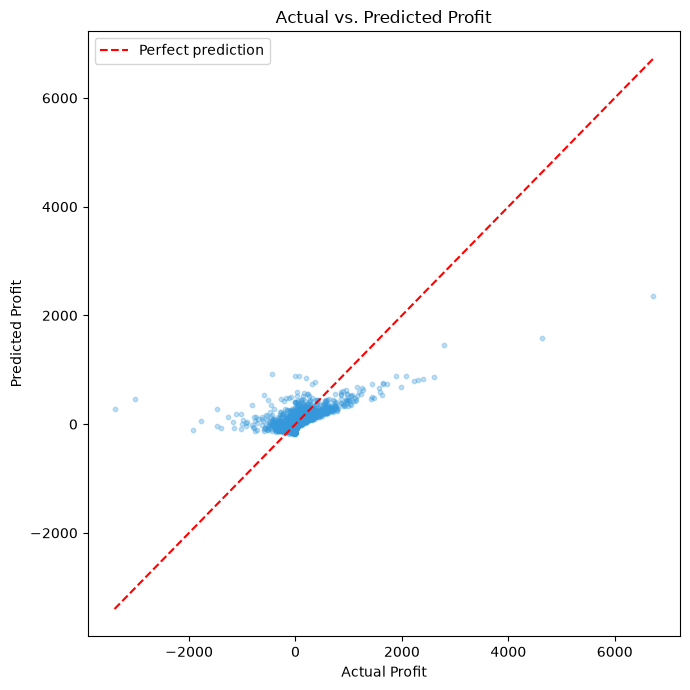

In [6]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions, alpha=0.3, s=10, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs. Predicted Profit')
plt.legend()
plt.tight_layout()
plt.savefig('../images/actual_vs_predicted.png')
plt.show()

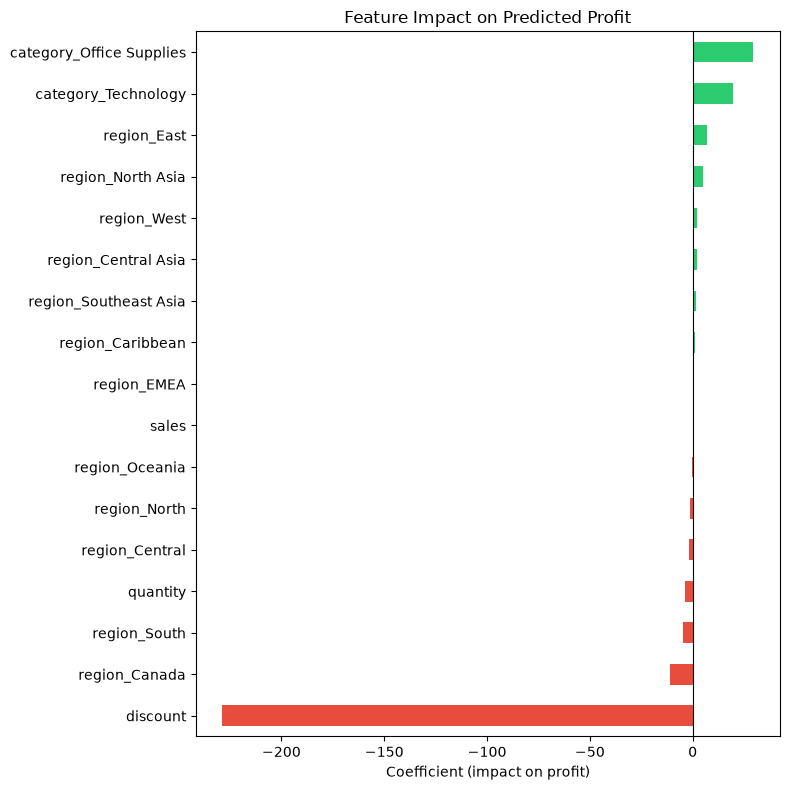

In [8]:
importance = pd.Series(model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8,8))
importance.plot(kind='barh', color=['#e74c3c' if x < 0 else '#2ecc71' for x in importance])
plt.title('Feature Impact on Predicted Profit')
plt.xlabel('Coefficient (impact on profit)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.show()